In [1]:
import pandas as pd
from utils import *
from tqdm import tqdm

df = pd.read_csv("data/recruiting_marketing_updated.csv")

# Recruitment Marketing Survey - How Different Demographies Should Be Approached For A Job Posting?

The goal of this notebook is to perform some exploratory data analysis on the results of a survey shared online. The survey aimed at understading how different demographic groups valued different aspects of job positions announcements made through different channels. 

In this exploratory data analysis, we will use data visualization techniques and statistical tests to validate some hypothesis and answer some questions such as:

- Do Gen-Z people consider more important for a job posting to expose the sallary than other generations?
- Which is the best channel for a job posting to get to you?

Among others.

## 1. Data Encoding

Let's see which categorial variables can be cast to integers for better analysis.

In [2]:
df.dtypes

datetime                                                                                                                               object
agree_to_participate_in_survey                                                                                                          int64
legal_age                                                                                                                               int64
age                                                                                                                                    object
gender                                                                                                                                 object
state                                                                                                                                  object
city                                                                                                                                   object
educat

In [3]:
col = 'about_the_company_importance'
df[col].unique()

array([nan,  3.,  2.,  4.,  1.,  0.])

In [4]:
# The column 'about_the_company_importance' contains nan values, let's check how many
df[col].isna().sum()

np.int64(4)

In [5]:
# There are few nan values in the column 'about_the_company_importance', let's fill them with 1
df[col] = df[col].fillna(1)

In [6]:
# Let's check which other columns have nan values
for col in df.columns:
    nan_values = df[col].isna().sum()
    if nan_values > 0:
        print(f"'{col}': {nan_values} nan values")

'monthly_family_income': 1 nan values
'Você tem alguma sugestão e/ou comentário sobre como as empresas podem melhorar suas estratégias de divulgação de vagas de emprego?': 215 nan values


- The `monthly_family_income` column has 1 nan value, let's undertand its values in order to fill it with the most appropriate value
- The `Você tem alguma sugestão e/ou comentário sobre como as empresas podem melhorar suas estratégias de divulgação de vagas de emprego?` column contains text data, let's deal with it later.

In [7]:
col = 'monthly_family_income'
df[col].unique()

array([nan, 'De R$ 3.001,00 a R$ 5.000,00',
       'De R$ 10.001,00 a R$ 20.000,00', 'De R$ 5.001,00 a R$ 10.000,00',
       'De R$ 1.001,00 a R$ 2.000,00', 'De R$ 2.001,00 a R$ 3.000,00',
       'De R$ 20.001,00 a R$ 100.000,00', 'R$ 100.001,00 ou mais',
       'De R$ 501,00 a R$ 1.000,00', 'Até R$ 500,00'], dtype=object)

We see that the `monthly_family_income` column contains non overlapping income ranges defined as strings. Hence, using the mode range to fill the missing value in this column is a reasonable approach.

In [8]:
# The column 'monthly_family_income' has 1 nan value, let's fill it with the median value
df[col] = df[col].fillna(df[col].mode())

We are ready to see how the different demographic groups value the different aspects of job postings. For that, we will calculate the distribution of the `*_importance` columns conditioned to the different demographic groups.

## 1.1 Category Aggregation

Some variables have too many categories given the number of samples in the dataset. We will aggregate some of them to make the analysis easier and more insightful.

In [9]:
for col in df.columns:
    if "_importance" not in col:
        print(f"Col: {col} has {df[col].unique().shape[0]} unique values") 

Col: datetime has 318 unique values
Col: agree_to_participate_in_survey has 1 unique values
Col: legal_age has 1 unique values
Col: age has 11 unique values
Col: gender has 3 unique values
Col: state has 13 unique values
Col: city has 72 unique values
Col: education_level has 7 unique values
Col: education_level_ibge has 3 unique values
Col: monthly_family_income has 9 unique values
Col: time_in_job_market has 5 unique values
Col: employment_situation has 4 unique values
Col: job_level has 15 unique values
Col: professional_activity has 38 unique values
Col: main_job_search_channel has 10 unique values
Col: most_likely_communication_channel_to_impact_respondent has 73 unique values
Col: Você já deixou de se candidatar a uma vaga devido à má reputação da empresa? has 2 unique values
Col: Você tem alguma sugestão e/ou comentário sobre como as empresas podem melhorar suas estratégias de divulgação de vagas de emprego? has 88 unique values


In [10]:
GROUPS_MAPS = {}

### 1.1.1 `age` Column

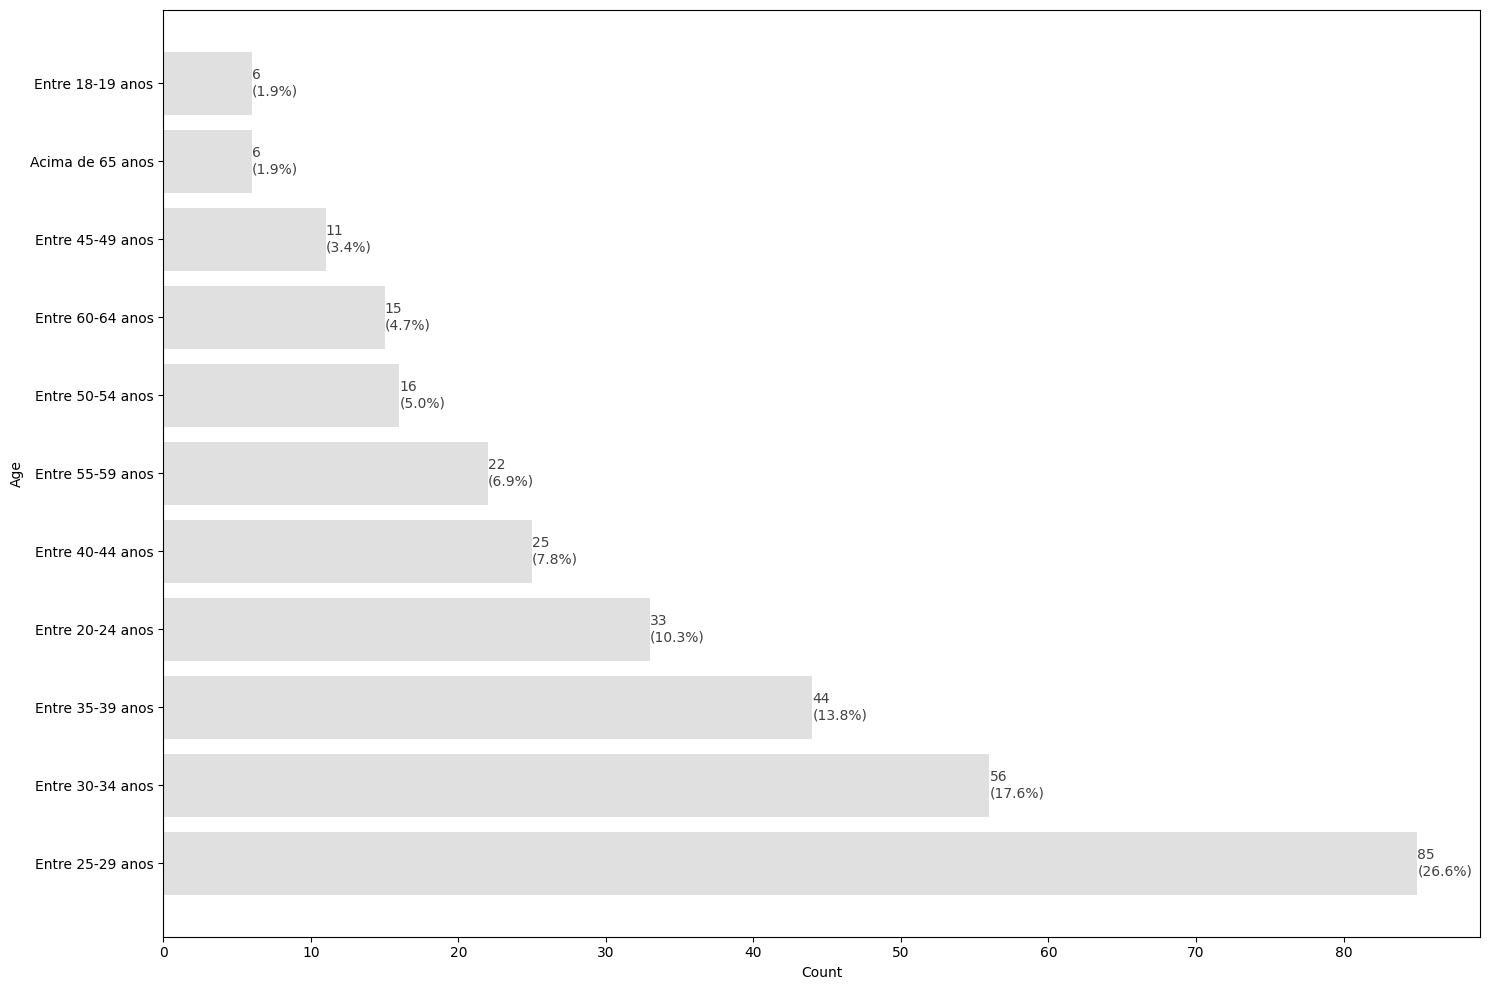

In [11]:
# The age column has too many unique values, let's check the distribution
plot_column_histogram(df, 'age', xlabel='Count', ylabel='Age')

Let's make the transformations:

- `age`: we will group the ages so that we only have 6 groups, with one of them being equivalent to `65+

In [12]:
# Let's remove the first and last words of the column
transform = lambda x: x.split()[1] if x.startswith('Entre') else x
df['age'] = df['age'].apply(transform)

# Each value in the age column is a closed interval represented in a string
# Let's turn them into a tuple of integers
transform = lambda x: tuple(map(int, x.split('-'))) if not x.startswith('Acima') else (int(x.split()[2]),)
df['age'] = df['age'].apply(transform)
df['age'].unique()

array([(30, 34), (25, 29), (50, 54), (40, 44), (35, 39), (55, 59), (65,),
       (20, 24), (60, 64), (18, 19), (45, 49)], dtype=object)

In [13]:
cast_age_to_buckets = {(18,19): (18,24),
                       (20,24): (18,24),
                       (25,29): (25,34),
                       (30,34): (25,34),
                       (35,39): (35,44),
                       (40,44): (35,44),
                       (45,49): (45,54),
                       (50,54): (45,54),
                       (55,59): (55,64),
                       (60,64): (55,64),
                       (65,): (65,)}
transform = lambda x: cast_age_to_buckets[x]
df['age'] = df['age'].apply(transform)

# Let's define the order of the age intervals so we can plot them in the correct order
age_order = sorted(df['age'].unique(), key=lambda x: (x[0], x[1]) if len(x) == 2 else (x[0],))
age_order_map = {age: i for i, age in enumerate(age_order)}
df['age_group'] = df['age'].apply(lambda x: age_order_map[x])

In [14]:
GROUPS_MAPS['age_group'] = age_order_map

### 1.1.2 `monthly_family_income` Column

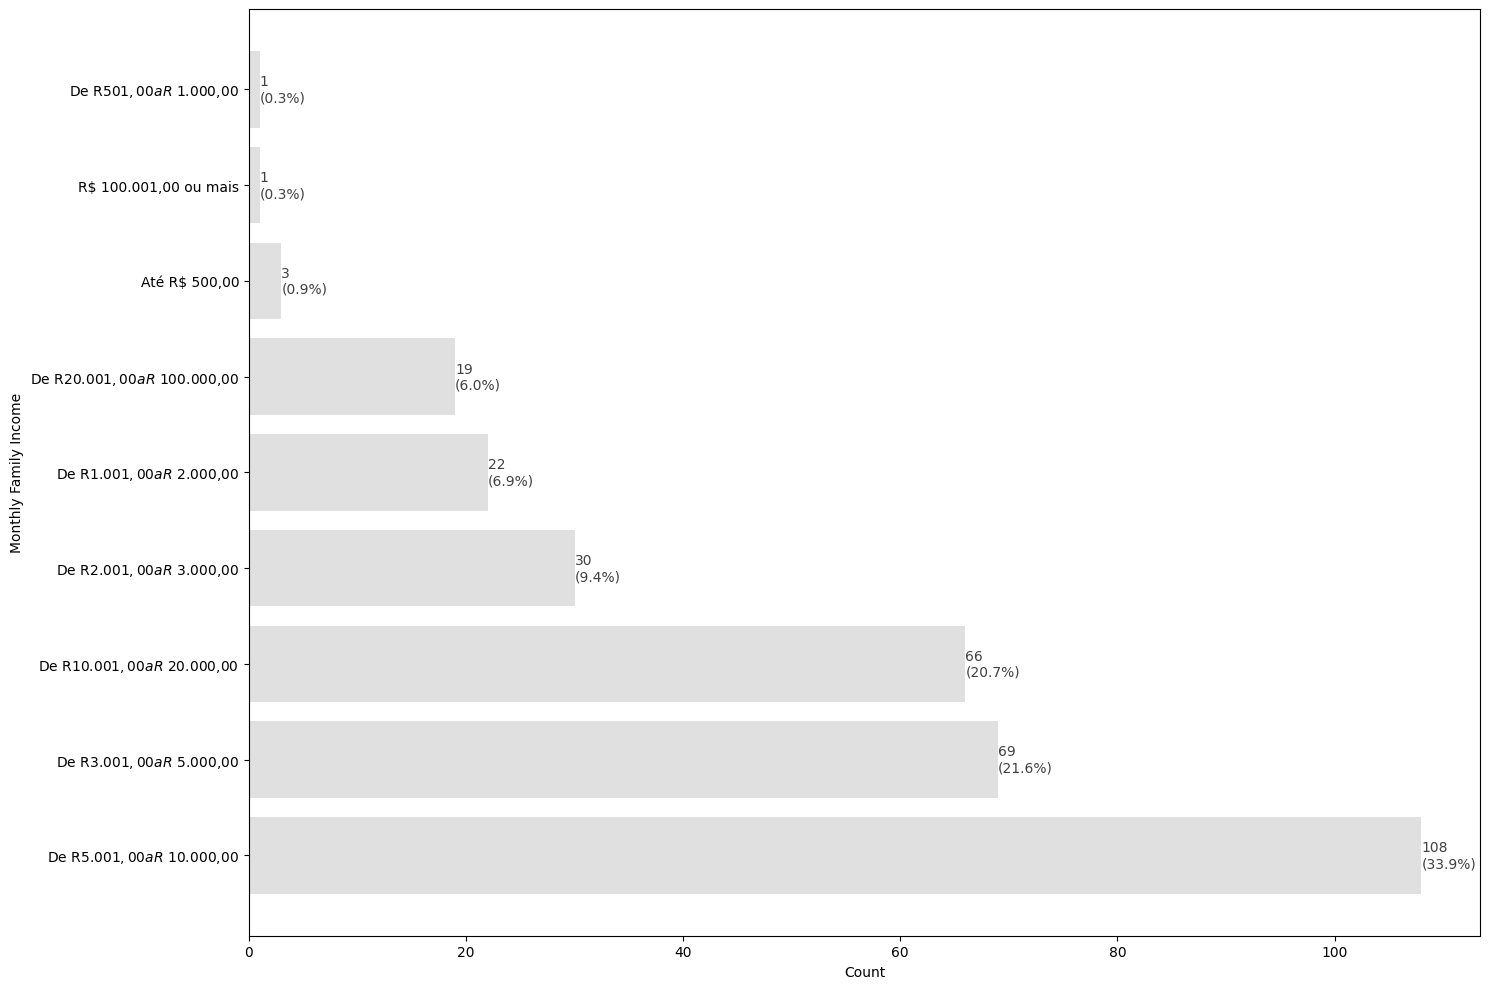

In [15]:
plot_column_histogram(df, 'monthly_family_income', xlabel='Count', ylabel='Monthly Family Income')

Let's begin by removing some words of the monthly income column so we can better understand it and make a decision on how to aggregate it.

In [16]:
# Let's first substitute . with nothing
transform = lambda x: x.replace('.', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
# Let's substitute , with .
transform = lambda x: x.replace(',', '.')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
# Let's substitute money signs with nothing 
transform = lambda x: x.replace('R$', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: x.replace('R', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
# Let's substitute the interval indicator with nothing
transform = lambda x: x.replace('ou mais', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: x.replace('a', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: x.replace('De', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: x.replace('Até', '')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)

transform = lambda x: x.replace('500.00', '0 500.00')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: x.replace('100001.00', '100001.00 200000')
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
# Let's create the tuples that represent income intervals

transform = lambda x: tuple(map(float, x.split()))
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: (int(x[0]), int(x[1])) if len(x) == 2 else (int(x[0]),)
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)


df['monthly_family_income'].unique()

array([(5001, 10000), (3001, 5000), (10001, 20000), (1001, 2000),
       (2001, 3000), (20001, 100000), (100001, 200000), (501, 1000),
       (0, 500)], dtype=object)

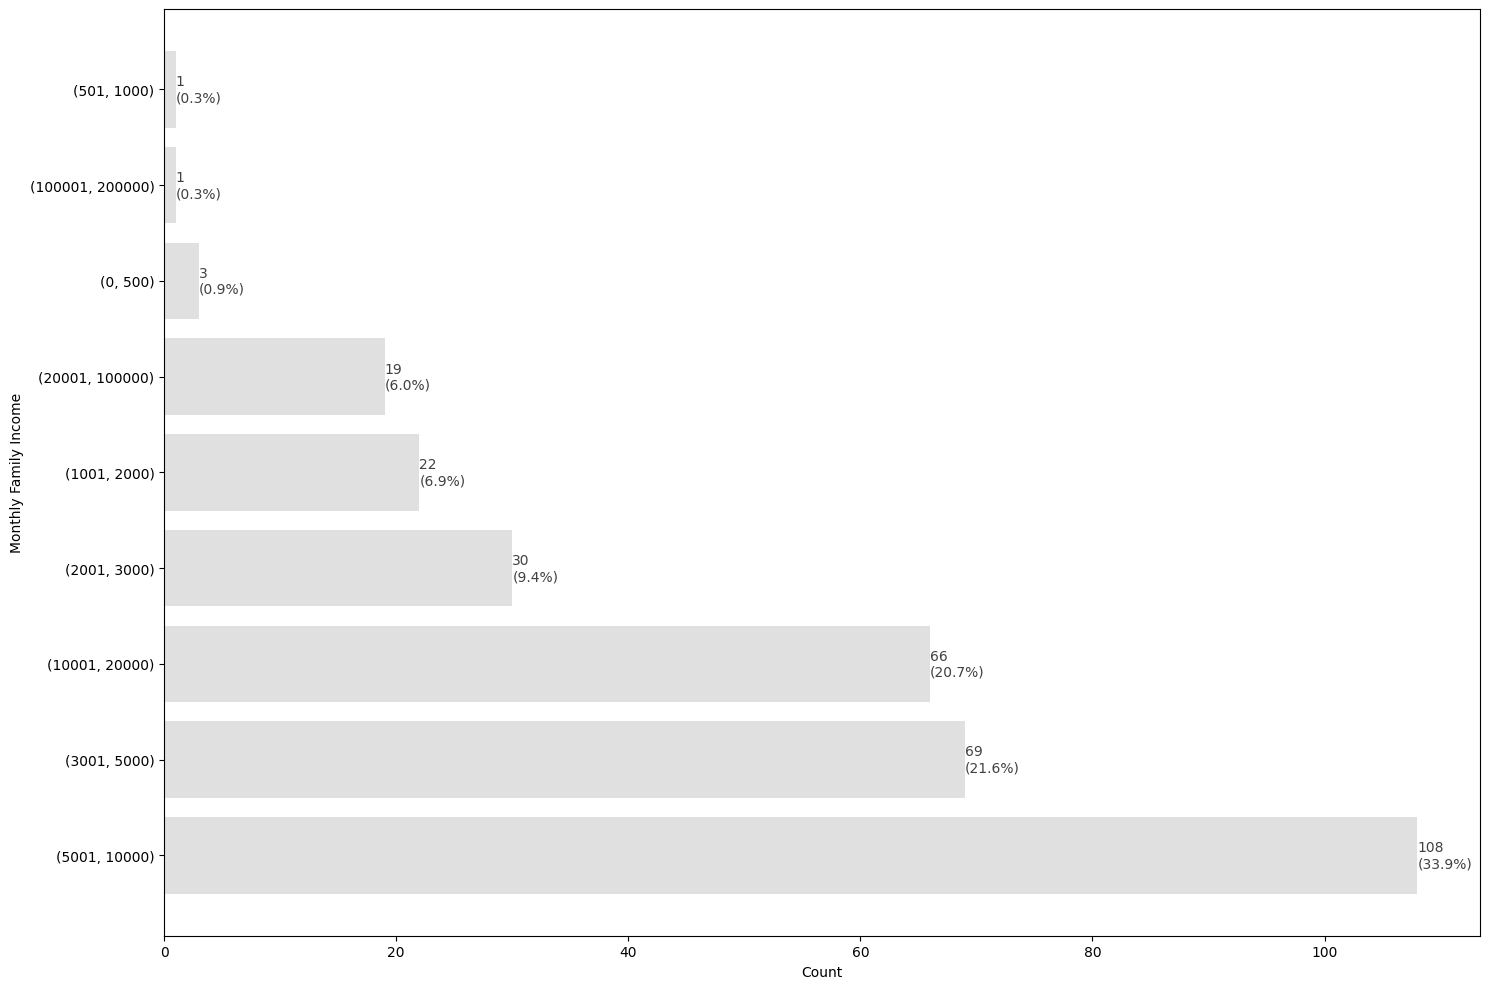

In [17]:
transform = lambda x: str(x)
df['monthly_family_income_str'] = df['monthly_family_income'].apply(transform)
plot_column_histogram(df, 'monthly_family_income_str', xlabel='Count', ylabel='Monthly Family Income')

- `monthly_family_income`: we will group the income ranges so that we only have 5 groups

In [18]:
cast_income_to_buckets = {(0, 500):  (0,2000),
                          (501, 1000): (0, 2000),
                          (1001, 2000): (0, 2000),
                          (2001, 3000): (2001, 5000),
                          (3001, 5000): (2001, 5000),
                          (100001, 200000): (100001, )}
transform = lambda x: cast_income_to_buckets[x] if x in cast_income_to_buckets else x
df['monthly_family_income'] = df['monthly_family_income'].apply(transform)
transform = lambda x: str(x)
df['monthly_family_income_str'] = df['monthly_family_income'].apply(transform)

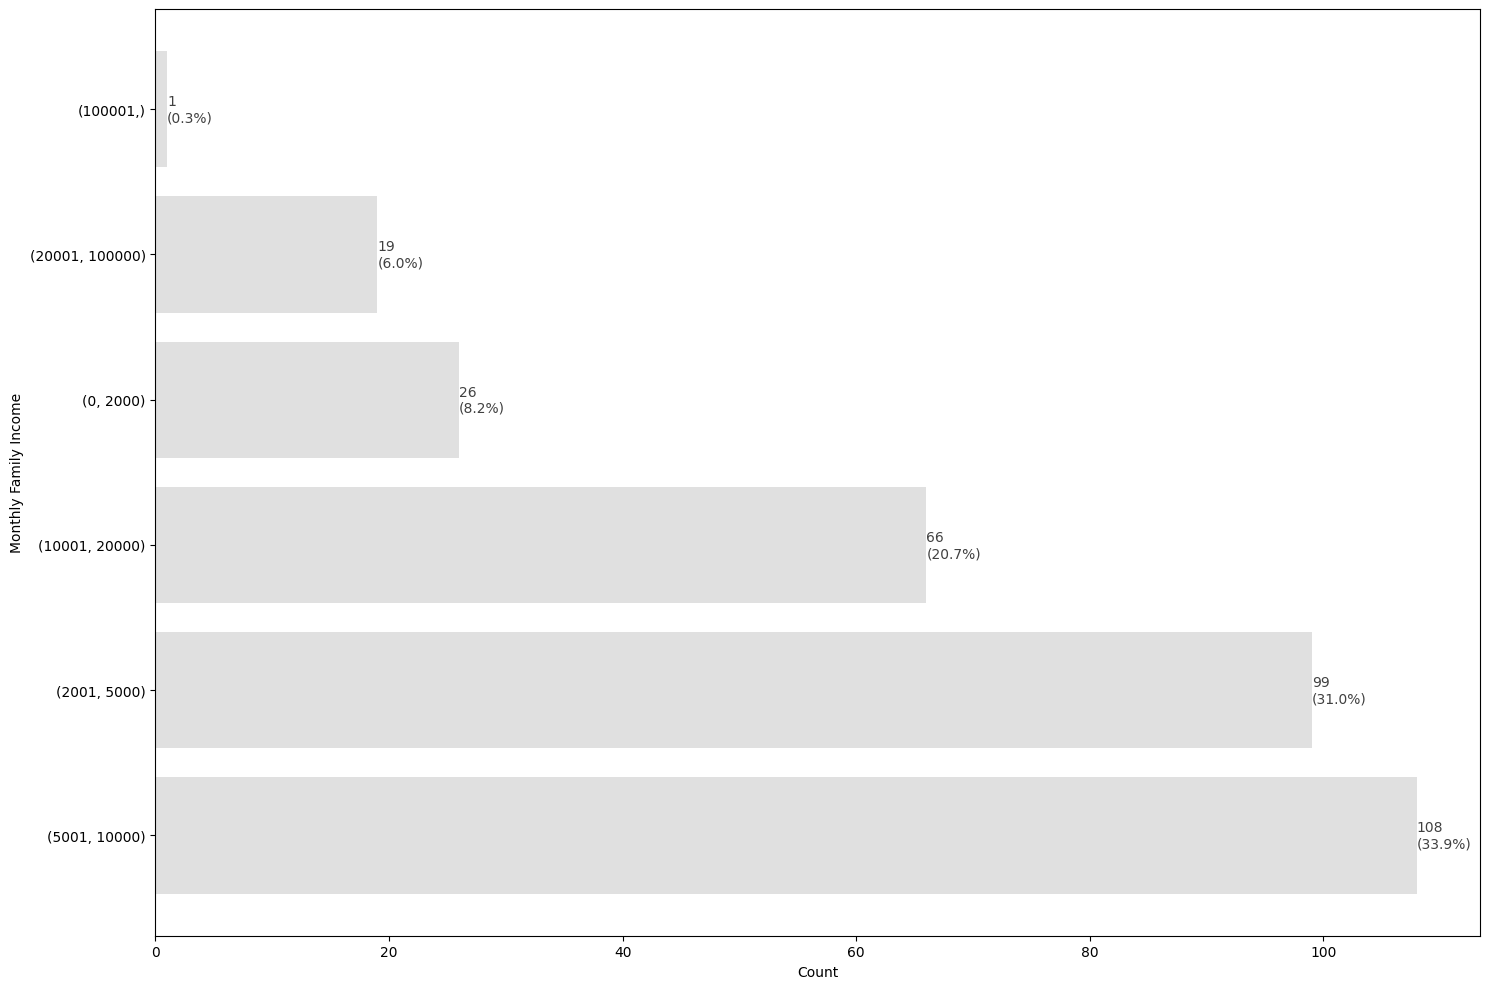

In [19]:
plot_column_histogram(df, 'monthly_family_income_str', xlabel='Count', ylabel='Monthly Family Income')

In [20]:
# Let's define the order of the income intervals so we can plot them in the correct order
income_order = sorted(df['monthly_family_income'].unique(), key=lambda x: (x[0], x[1]) if len(x) == 2 else (x[0],))
income_order_map = {income: i for i, income in enumerate(income_order)}
df['income_group'] = df['monthly_family_income'].apply(lambda x: income_order_map[x])

In [21]:
GROUPS_MAPS['income_group'] = income_order_map

### 1.1.3 `education_level_ibge` Column

In [22]:
df['education_level_ibge'].unique()

array(['Superior completo', 'Médio completo e superior incompleto',
       'Fundamental completo e médio incompleto'], dtype=object)

In [23]:
education_level_ibge_order_map = {'Fundamental completo e médio incompleto': 0,
                                  'Médio completo e superior incompleto': 1,
                                  'Superior completo': 2}
df['education_level_ibge_group'] = df['education_level_ibge'].map(education_level_ibge_order_map)

In [24]:
GROUPS_MAPS['education_level_ibge_group'] = education_level_ibge_order_map

### 1.1.4 `education_level` Column

In [25]:
df['education_level'].unique()

array(['Pós-graduação completa', 'Ensino Superior completo',
       'Ensino Médio completo', 'Pós-gradução incompleta',
       'Ensino Superior incompleto', 'Ensino Fundamental completo',
       'Ensino Médio incompleto'], dtype=object)

In [26]:
education_level_order_map = {'Ensino Fundamental completo': 0,
                             'Ensino Médio incompleto': 1,
                             'Ensino Médio completo': 2,
                             'Ensino Superior incompleto': 3,
                             'Ensino Superior completo': 4,
                             'Pós-gradução incompleta': 5,
                             'Pós-gradução completa': 6}
df['education_level_group'] = df['education_level'].map(education_level_ibge_order_map)

In [27]:
GROUPS_MAPS['education_level_group'] = education_level_order_map

### 1.1.5 `employment_situation` Column

In [28]:
df['employment_situation'].unique()

array(['Empregado', 'Empregado(a)', 'Aposentado(a)', 'Desempregado(a)'],
      dtype=object)

In [29]:
employment_situation_order_map = {'Desempregado(a)': 0,
                             'Empregado': 1,
                             'Empregado(a)': 1,
                             'Aposentado(a)': 2}
df['employment_situation_group'] = df['employment_situation'].map(education_level_ibge_order_map)

In [30]:
GROUPS_MAPS['employment_situation_group'] = employment_situation_order_map

### 1.1.6 `job_level` Column

In [31]:
df['job_level'].unique()

array(['Especialista', 'Analista Júnior', 'Analista Sênior',
       'Analista Pleno', 'Autônomo(a)', 'Gerente',
       'Coordenador(a) ou Supervisor(a)', 'Assistente', 'CEO',
       'Auxiliar ou Ajudante', 'Aposentado(a)', 'Jovem Aprendiz',
       'Diretor(a)', 'Técnico(a)', 'Estagiário(a)'], dtype=object)

In [32]:
job_level_order_map = {i: i for i in df['job_level'].unique()}
df['job_level_group'] = df['job_level']

In [33]:
GROUPS_MAPS['job_level_group'] = job_level_order_map

### 1.1.7 `professional_activity` Column

In [34]:
df['professional_activity'].unique()

array(['Educação', 'Tecnologia da Informação', 'Finanças e Contabilidade',
       'Comércio Exterior', 'Administração e Negócios',
       'Turismo e Hospitalidade', 'Saúde', 'Marketing e Publicidade',
       'Logística', 'Serviços Gerais', 'Recursos Humanos', 'Beleza',
       'Vendas e Comércio', 'Aposentado(a)', 'Militar',
       'Telecomunicações', 'Comunicação e Jornalismo', 'Direito',
       'Produção e Manufatura', 'Artes e Design', 'Construção Civil',
       'Agricultura e Meio Ambiente', 'Cuidador(a)', 'Recepção',
       'Customer Experience', 'Relações Internacionais', 'Gastronomia',
       'Eventos', 'Auxiliar de Diagramação', 'Operações de Produção',
       'Transporte e Entrega', 'Freelancer', 'Arquitetura e Urbanismo',
       'Segurança do Trabalho', 'Farmacêutica e/ou Química',
       'Serviços Sociais e Comunitários', 'Ciências e Pesquisa',
       'Engenharia'], dtype=object)

In [35]:
prof_act_order_map = {i: i for i in df['professional_activity'].unique()}
df['professional_activity_group'] = df['professional_activity']

In [36]:
GROUPS_MAPS['professional_activity_group'] = prof_act_order_map

# 2. Data Analysis

## 2.1 Importance Given to Offered Benefits Demographic Groupd Hypothesis

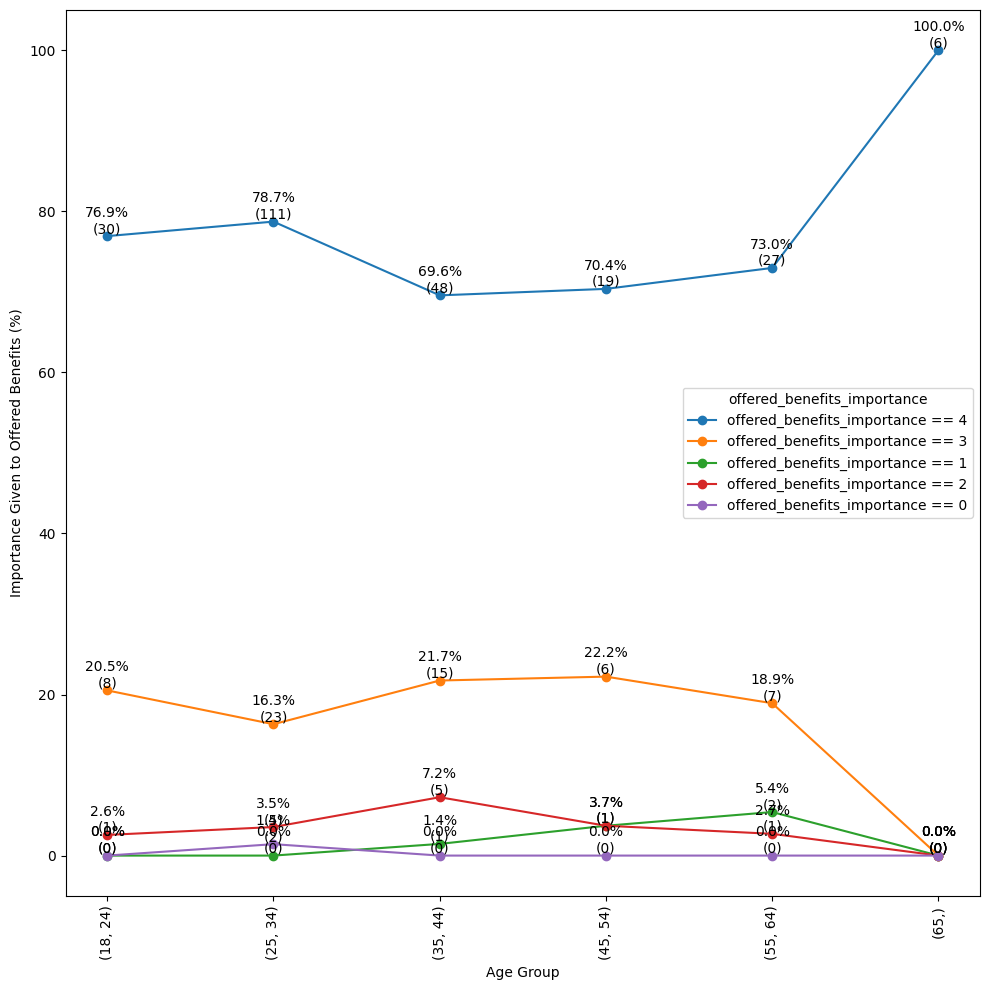

In [37]:
group_by_column = 'age_group'
importance_column = 'offered_benefits_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to Offered Benefits (%)'
figsize = (10,10)
xticks = age_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Muito Importante' (`offered_benefits_importance == 4`) to the offered benefits is higher for people that are in the age group `(25,34)` than for people that are in other age groups.

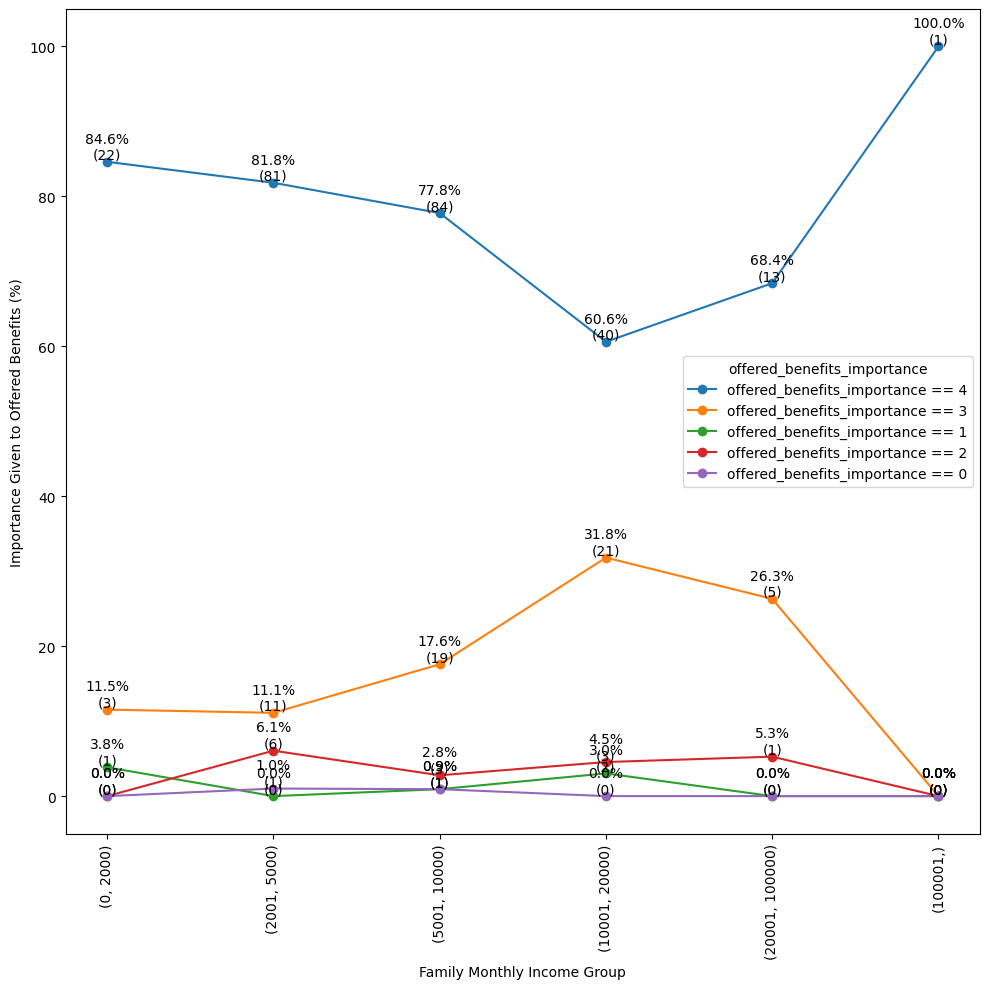

In [38]:
group_by_column = 'income_group'
importance_column = 'offered_benefits_importance'
xlabel = 'Family Monthly Income Group'
ylabel = 'Importance Given to Offered Benefits (%)'
figsize = (10,10)
xticks = income_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`offered_benefits_importance == 2`) to the offered benefits is higher for people that are in the family income group `(0, 10000)` than for people that are in the family income group `10000+`.

## 2.2 Importance Given to Detailed Job Description Demographic Groups Hypothesis

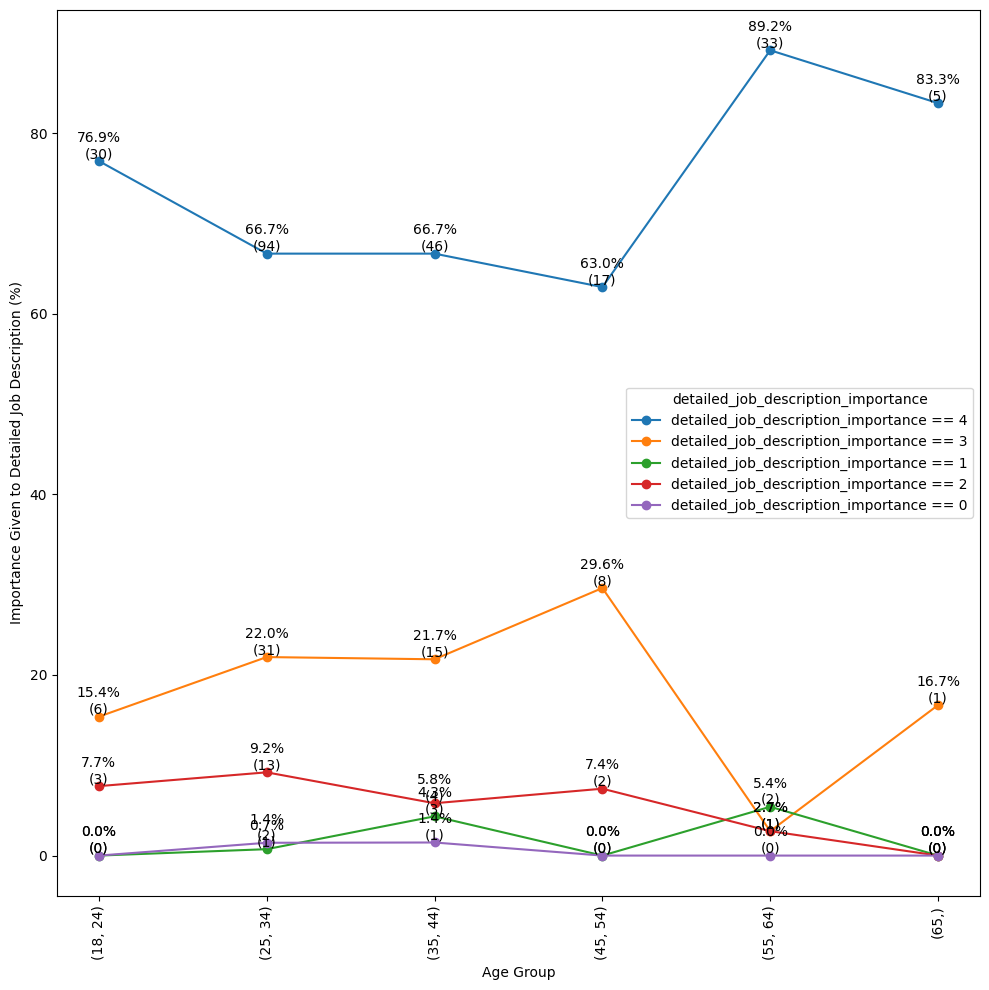

In [39]:
group_by_column = 'age_group'
importance_column = 'detailed_job_description_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to Detailed Job Description (%)'
figsize = (10,10)
xticks = age_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`detailed_job_description_importance == 4`) to the details of a job description in a job offer is higher for people that are in the age group `55-64` than for people that are other groups

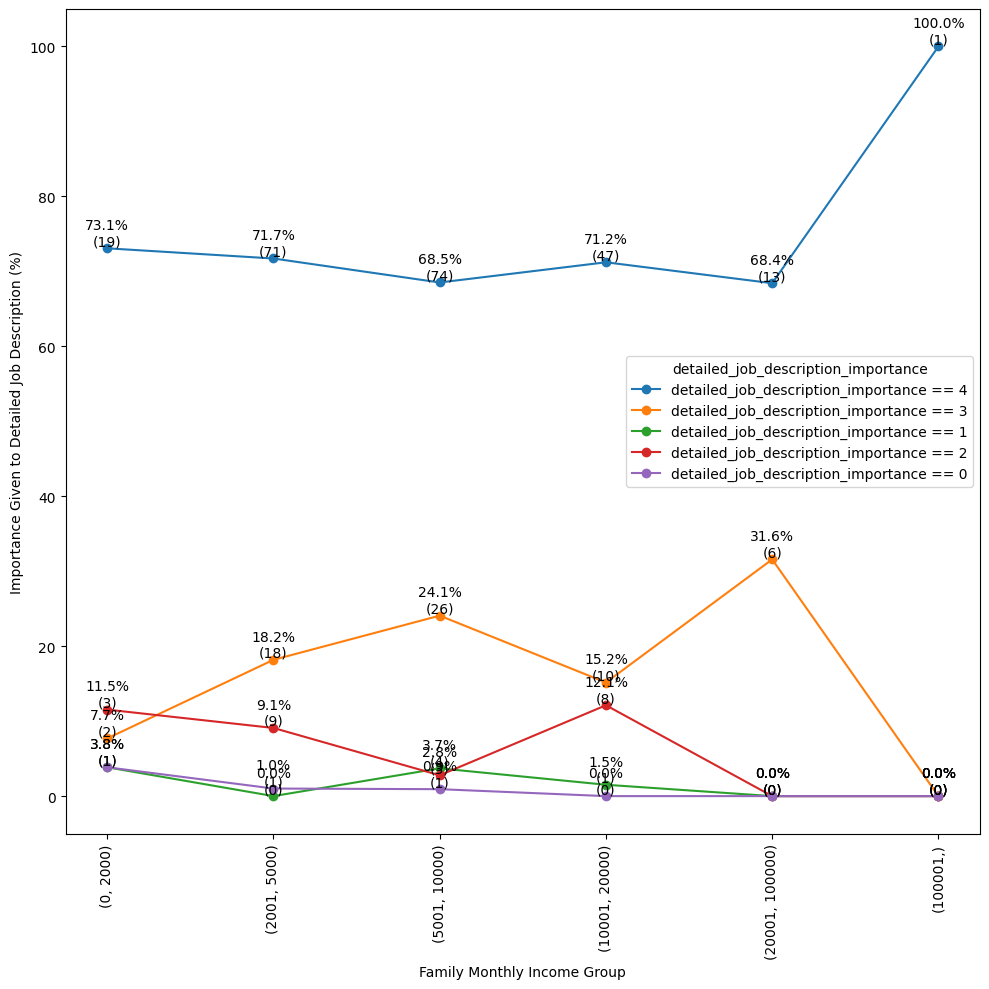

In [40]:
group_by_column = 'income_group'
importance_column = 'detailed_job_description_importance'
xlabel = 'Family Monthly Income Group'
ylabel = 'Importance Given to Detailed Job Description (%)'
figsize = (10,10)
xticks = income_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the details of a job description is not equally important for all family income groups.
    - We disregard the `100000+` group because it has only 1 sample.

## 2.3 Importance Given to Salary Demographic Groups Hypothesis

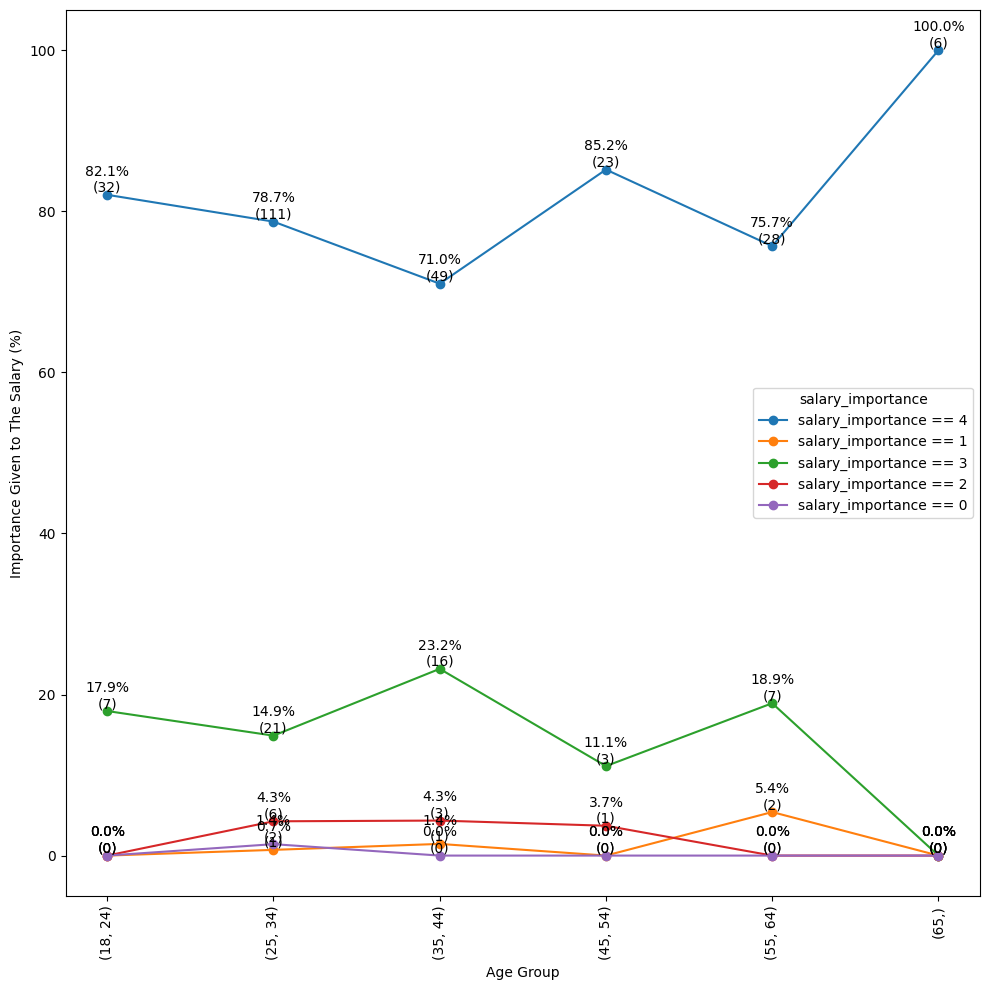

In [41]:
group_by_column = 'age_group'
importance_column = 'salary_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to The Salary (%)'
figsize = (10,10)
xticks = age_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`salary_importance == 2`) to the salary of a job offer is lower for people that are in the age group `25-44` than for people that are younger than 25 or older than 44.

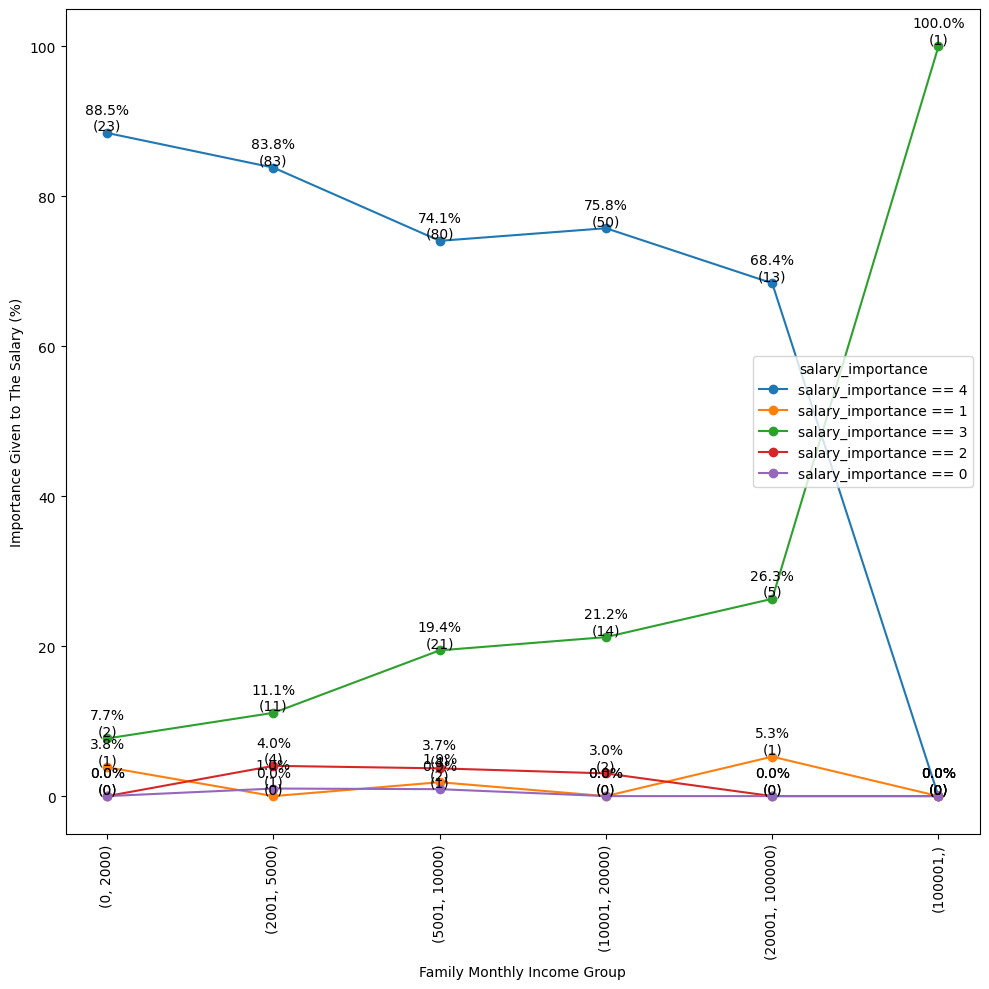

In [42]:
group_by_column = 'income_group'
importance_column = 'salary_importance'
xlabel = 'Family Monthly Income Group'
ylabel = 'Importance Given to The Salary (%)'
figsize = (10,10)
xticks = income_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`salary_importance == 2`) to the salary of a job offer is lower for people that are in the family monthly income group `(2001,10000)` than for those that are in the family monthly income group `(10001,100000)` .
    - We disregard the `100000+` group because it has only 1 sample.

- Hypothesis: the average of people that gives 'Alta Importancia' (`salary_importance == 2`) to the salary of a job offer is lower for people that are in the family monthly income group `(2001,10000)` than for those that are in the family monthly income group `(0,20000)` .

## 2.4 Importance Given to Career Plan Demographic Groups Hypothesis

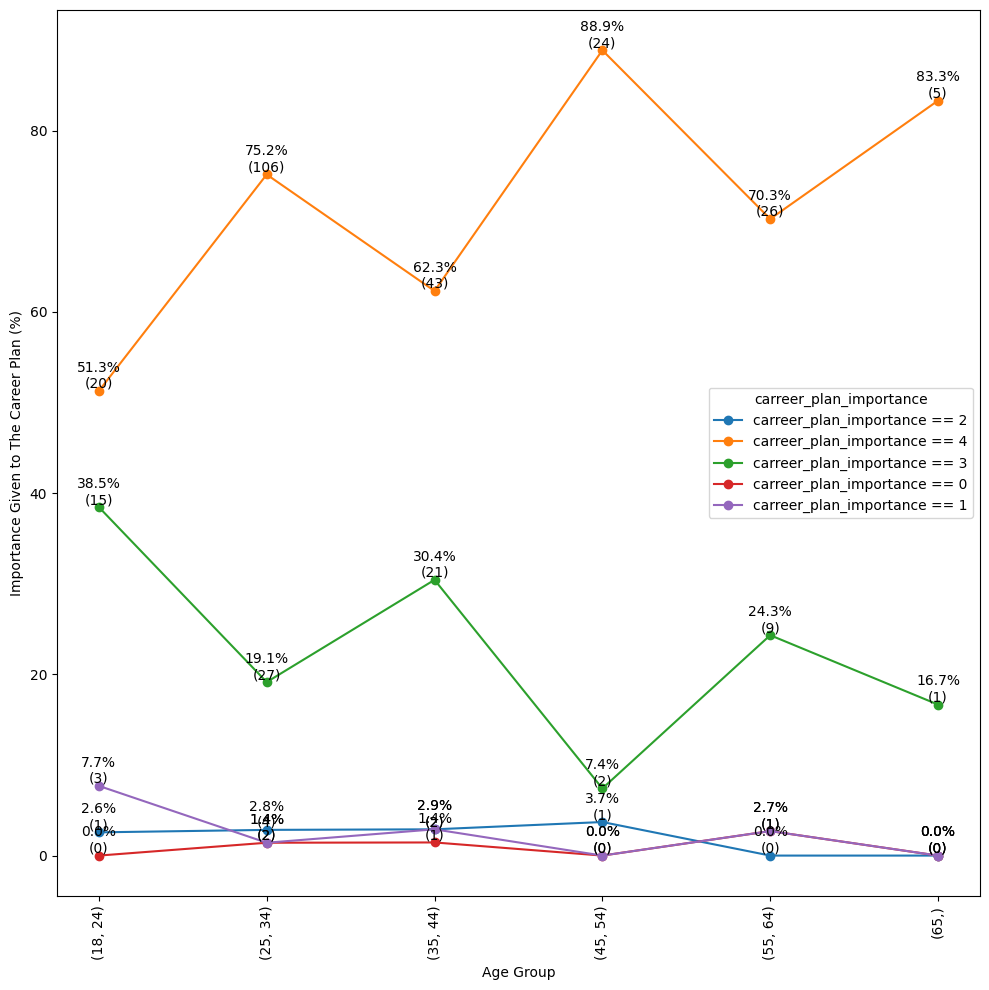

In [43]:
group_by_column = 'age_group'
importance_column = 'carreer_plan_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to The Career Plan (%)'
figsize = (10,10)
xticks = age_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`carreer_plan_importance == 2`) to the career plan of a job offer is higher for people that are in the age group `45+` than for people that are in the age group `(0, 44)`

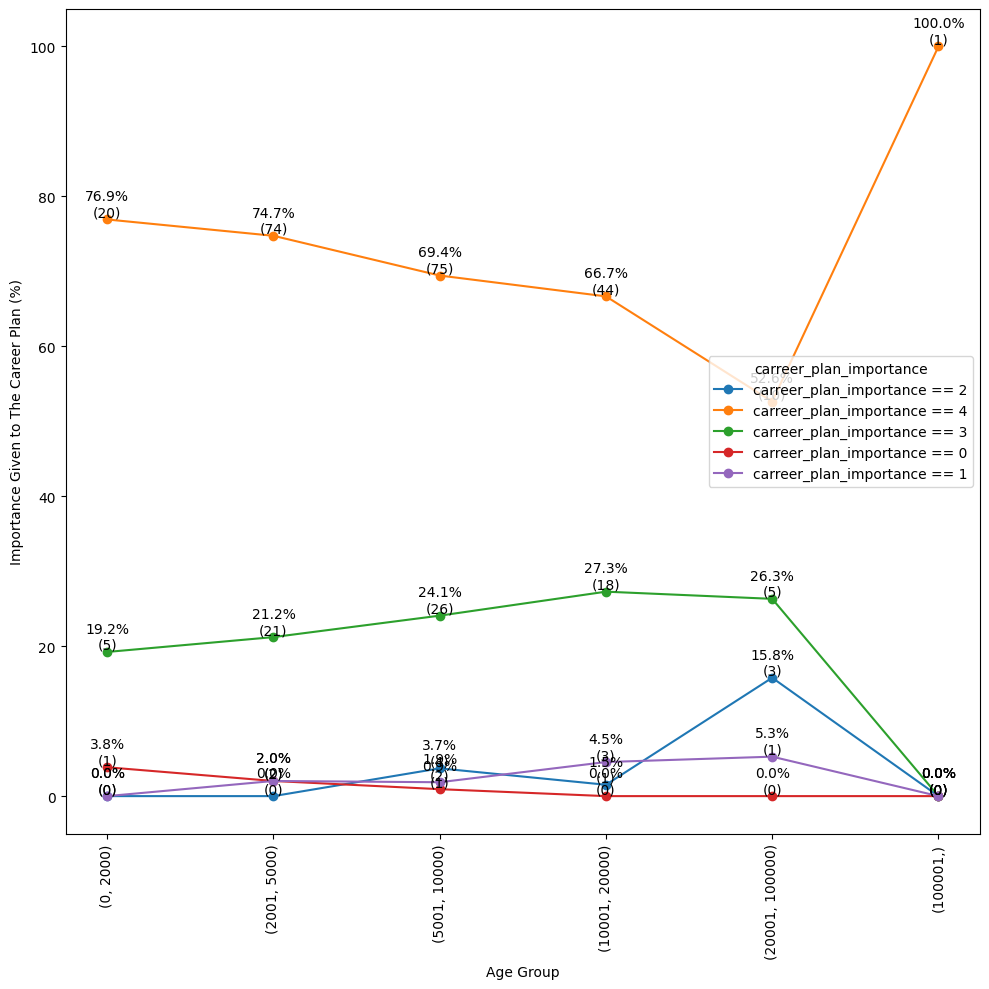

In [44]:
group_by_column = 'income_group'
importance_column = 'carreer_plan_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to The Career Plan (%)'
figsize = (10,10)
xticks = income_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`carreer_plan_importance == 2`) to the career plan of a job offer is higher for people that are in the family monthly income group `(0, 20000)` than for people that are in the family monthly income group `(20001, 100000)`.

## 2.5 Work Life Balance Importance Demographic Groups Hypothesis

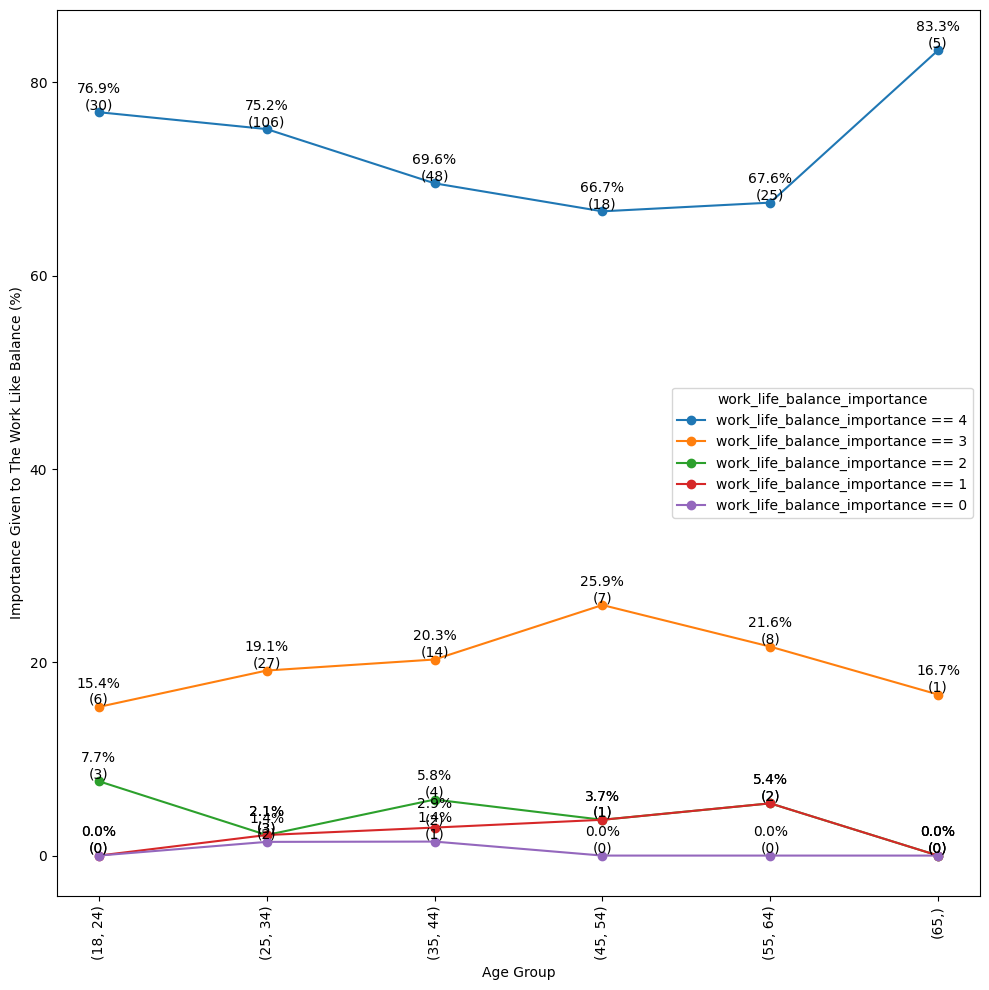

In [45]:
group_by_column = 'age_group'
importance_column = 'work_life_balance_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to The Work Like Balance (%)'
xticks = age_order_map.keys()
figsize = (10,10)
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, xticks=xticks, ylabel = ylabel, figsize=figsize)


- Hypothesis: Age groups value less the work life balance than they value the salary of a job offer or the career plan of a job offer.

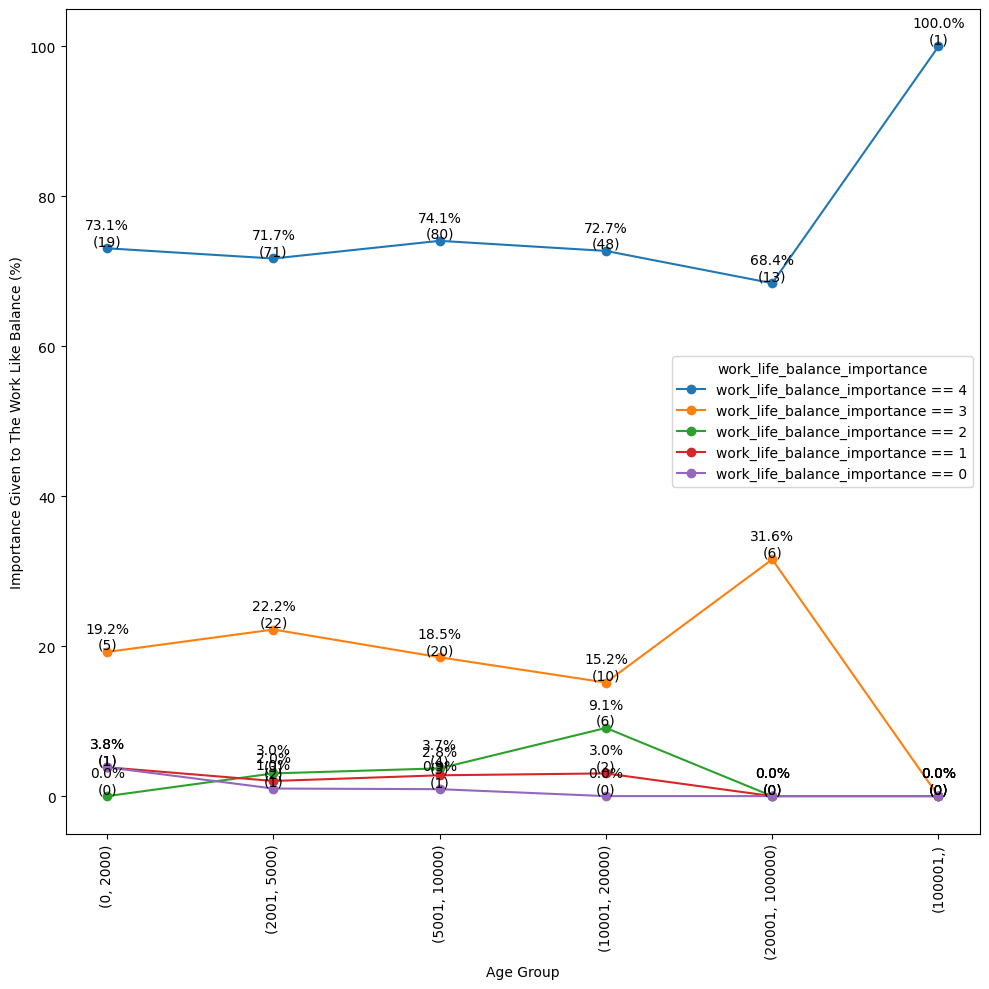

In [46]:
group_by_column = 'income_group'
importance_column = 'work_life_balance_importance'
xlabel = 'Age Group'
ylabel = 'Importance Given to The Work Like Balance (%)'
figsize = (10,10)
xticks = income_order_map.keys()
plot_percentages_line_plot_all_groups(df = df, group_by_column = group_by_column, count_column = importance_column, xlabel = xlabel, ylabel = ylabel, xticks=xticks, figsize=figsize)


- Hypothesis: the average of people that gives 'Alta Importancia' (`work_life_balance_importance == 2`) to the work like balance of a job offer is higher for people that are in the family monthly income group `(0, 20000)` than for people that are in the family monthly income group `(20001, 100000)`.

# 3. Hypothesis Tests (T-Tests)

In [47]:
boot_samp_size = 10
pop_sizes = 100
alfa = 0.05

In [48]:
from scipy import stats

def bootstrap_sample(col: str, group: str, n_samples: int, df: pd.DataFrame) -> pd.DataFrame:
    filtered_df = df[df[col]==group]
    out = filtered_df.sample(n=n_samples, replace=True)
    return out

def all_bootstrap_samples(col: str, group: str, col_of_interest: str, n_samples: int = boot_samp_size, df: pd.DataFrame = df, N: int = pop_sizes) -> pd.Series:
    out = []
    for _ in range(N):
        boot_samp = bootstrap_sample(col = col, group=group, n_samples=n_samples, df =df)[col_of_interest].values
        out.append(boot_samp)
    return out


def get_variable_of_interest_observations_normal_vector(pop_observations: list[pd.Series]) -> list[float]:
    out = []
    for obs in pop_observations:
        pop_mean = obs.mean()
        out.append(pop_mean)
    return out


def run_t_test(group_a, group_b, map, hyp_col, col_of_interest, hyps_df):
    hyp = f"The {col_of_interest} is less for the incomes group {group_a} than {group_b} "
    group = map[group_a]
    boots_samples = all_bootstrap_samples(col=hyp_col, group=group,col_of_interest=col_of_interest)
    group_a_avg = get_variable_of_interest_observations_normal_vector(boots_samples)

    group = map[group_b]
    boots_samples = all_bootstrap_samples(col=hyp_col, group=group,col_of_interest=col_of_interest)
    group_b_avg = get_variable_of_interest_observations_normal_vector(boots_samples)

    t_statistic, p_value_two_tailed  = stats.ttest_ind(group_a_avg, group_b_avg, alternative="less")
    p_value_one_tailed = p_value_two_tailed / 2
    if p_value_one_tailed < alfa:
        conclusion = True
    else:
        conclusion = False
    
    hyps_df.loc[len(hyps_df)] = [hyp,p_value_one_tailed,t_statistic,conclusion,group_a, group_b]
    return hyps_df


def get_group_size(df: pd.DataFrame, col: str, value) -> int:
    filtered_df = df[df[col]==value]
    return len(filtered_df)


In [49]:
import itertools

groups_pairs = {}
for group_name, group_map in GROUPS_MAPS.items():
    groups = group_map.keys()
    groups_pairs[group_name] =  list(itertools.permutations(groups, 2))

In [50]:
groups_sizes = {}
for group_col, pairs in groups_pairs.items():
    groups_sizes[group_col] = {}
    for group_a, group_b in pairs:
        group_a = GROUPS_MAPS[group_col][group_a]
        group_b = GROUPS_MAPS[group_col][group_b]
        groups_sizes[group_col][group_a] = get_group_size(df,group_col,group_a)
        groups_sizes[group_col][group_b] = get_group_size(df,group_col,group_b)

In [ ]:
hyps_df = pd.DataFrame(columns=["Hypothesis", "p-value","t-test","Conclusion", "Group A", "Group B"])

cols_of_importance = [col for col in df.columns if "importance" in col]
for col in tqdm(cols_of_importance):
    for group_col, pairs in groups_pairs.items():
        map = GROUPS_MAPS[group_col]
        for group_a, group_b in pairs:
            if groups_sizes[group_col][map[group_a]] > 1 and groups_sizes[group_col][map[group_b]] > 1:
                hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=map, hyp_col=group_col, col_of_interest=col, hyps_df=hyps_df)


  0%|          | 0/15 [00:00<?, ?it/s]/Users/giovani.tavares/projects/recruitment_marketing/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/giovani.tavares/projects/recruitment_marketing/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/giovani.tavares/projects/recruitment_marketing/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may 

In [55]:
hyps_df.to_csv("final_t_test_results.csv")

In [ ]:
import itertools

hyps_df = pd.DataFrame(columns=["Hypothesis", "p-value","t-test","Conclusion"])
income_groups = income_order_map.keys()
income_pairs = list(itertools.permutations(income_groups, 2))
age_groups = age_order_map.keys()
age_pairs = list(itertools.permutations(age_groups, 2))

In order to run T-Tests to check our hypothesis, we need to make sure that the data is normally distributed. We will use the Bootstrap sampling method to create

## 3.1 Detailed Job Description Importance

In [ ]:
hyp_col =  'income_group'
col_of_interest = 'detailed_job_description_importance'
for group_a, group_b in income_pairs:
    if group_b != (100001,):
        hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=income_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

hyp_col =  'age_group'
for group_a, group_b in age_pairs:
    hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=age_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

## 3.2 Salary Importance

In [ ]:
hyp_col =  'income_group'
col_of_interest = 'salary_importance'
for group_a, group_b in income_pairs:
    if group_b != (100001,):
        hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=income_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)


hyp_col =  'age_group'
for group_a, group_b in age_pairs:
    hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=age_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

## 3.3 Salary Importance

In [ ]:
hyp_col =  'income_group'
col_of_interest = 'carreer_plan_importance'
for group_a, group_b in income_pairs:
    if group_b != (100001,):
        hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=income_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

hyp_col =  'age_group'
for group_a, group_b in age_pairs:
    hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=age_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

## 3.4 Work Life Balance Importance

In [ ]:
hyp_col =  'income_group'
col_of_interest = 'work_life_balance_importance'
for group_a, group_b in income_pairs:
    if group_b != (100001,):
        hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=income_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

hyp_col =  'age_group'
for group_a, group_b in age_pairs:
    hyps_df = run_t_test(group_a=group_a, group_b=group_b,map=age_order_map, hyp_col=hyp_col, col_of_interest=col_of_interest, hyps_df=hyps_df)

In [ ]:
hyps_df.to_csv("pleniminary_t_tests_results.csv")